Running on Kaggle
  TRAIN_DIR: /kaggle/input/datasets/danushkumarv/indian-monuments-image-dataset/Indian-monuments/images/train
  TEST_DIR : /kaggle/input/datasets/danushkumarv/indian-monuments-image-dataset/Indian-monuments/images/test
OUTPUT_DIR: /kaggle/working

=== Dataset Structure ===
  [train] Ajanta Caves: 96 images
  [train] Charar-E- Sharif: 168 images
  [train] Chhota_Imambara: 110 images
  [train] Ellora Caves: 110 images
  [train] Fatehpur Sikri: 42 images
  [train] Gateway of India: 203 images
  [train] Humayun_s Tomb: 166 images
  [train] India gate pics: 173 images
  [train] Khajuraho: 44 images
  [train] Sun Temple Konark: 159 images
  [train] alai_darwaza: 70 images
  [train] alai_minar: 140 images
  [train] basilica_of_bom_jesus: 100 images
  [train] charminar: 213 images
  [train] golden temple: 209 images
  [train] hawa mahal pics: 201 images
  [train] iron_pillar: 252 images
  [train] jamali_kamali_tomb: 206 images
  [train] lotus_temple: 100 images
  [train] myso

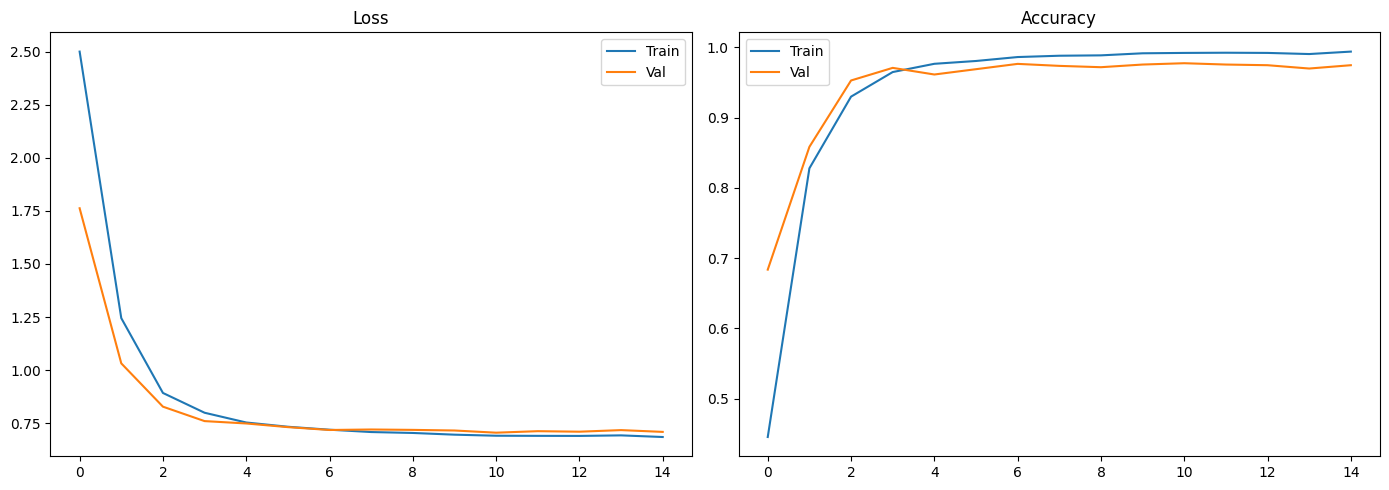


=== Classification Report ===
                       precision    recall  f1-score   support

         Ajanta Caves       1.00      1.00      1.00        31
     Charar-E- Sharif       1.00      1.00      1.00        34
      Chhota_Imambara       1.00      1.00      1.00        30
         Ellora Caves       0.97      1.00      0.99        34
       Fatehpur Sikri       1.00      1.00      1.00        42
     Gateway of India       1.00      1.00      1.00        30
       Humayun_s Tomb       1.00      1.00      1.00        30
      India gate pics       1.00      1.00      1.00        45
            Khajuraho       1.00      1.00      1.00        44
    Sun Temple Konark       1.00      1.00      1.00        40
         alai_darwaza       1.00      1.00      1.00        36
           alai_minar       0.97      1.00      0.99        35
basilica_of_bom_jesus       1.00      0.97      0.98        30
            charminar       1.00      0.72      0.84        40
        golden temple  

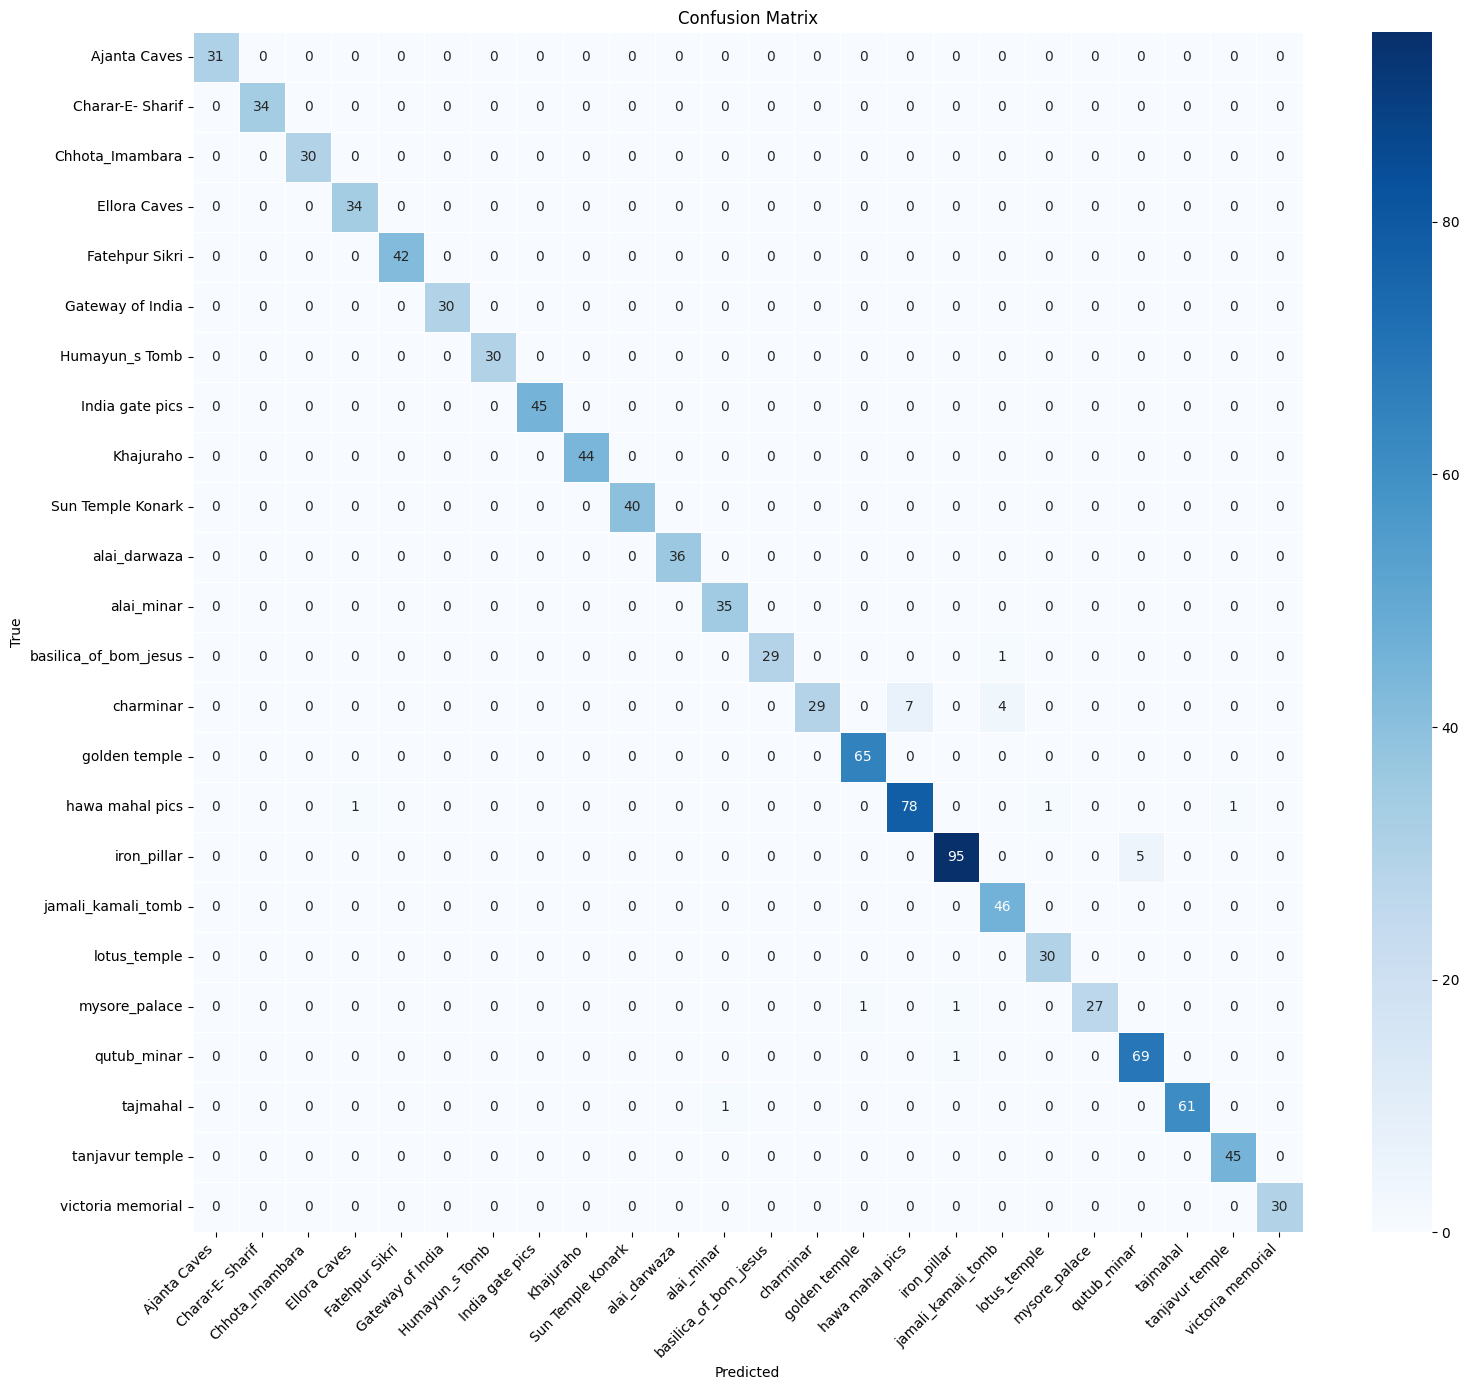


Outputs saved to: /kaggle/working
Done


In [8]:
# =============================================================
# T12.1 - Monuments & Heritage Identifier
# Top monuments fine-tuned
# Training Script
# Dataset: kaggle.com/datasets/danushkumarv/indian-monuments-image-dataset
# =============================================================

import os, json, random, shutil, subprocess, sys
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

KAGGLE_DATASET = "danushkumarv/indian-monuments-image-dataset"
DATASET_SLUG   = KAGGLE_DATASET.split("/")[1]   # indian-monuments-image-dataset

def is_kaggle() -> bool:
    return os.path.exists("/kaggle/input")

def is_colab() -> bool:
    try:
        import google.colab
        return True
    except ImportError:
        return False

def download_dataset_via_api(dest: Path):
    # Download the dataset using the kaggle api.
    dest.mkdir(parents=True, exist_ok=True)
    print(f"Downloading dataset '{KAGGLE_DATASET}' to {dest} ...")
    result = subprocess.run(
        [sys.executable, "-m", "kaggle", "datasets", "download",
         "-d", KAGGLE_DATASET,
         "--unzip",
         "-p", str(dest)],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print("STDERR:", result.stderr)
        raise RuntimeError(
            "Kaggle download failed. Make sure:\n"
            "  1) kaggle is installed:  pip install kaggle\n"
            "  2) Your API key is set:\n"
            "       export KAGGLE_USERNAME=your_username\n"
            "       export KAGGLE_KEY=your_api_key\n"
            "     OR place kaggle.json at ~/.kaggle/kaggle.json\n"
            "  3) You have accepted the dataset rules on kaggle.com"
        )
    print("Download complete")

# Resolve data_dir 
if is_kaggle():
    TRAIN_DIR  = Path("/kaggle/input/datasets/danushkumarv/indian-monuments-image-dataset/Indian-monuments/images/train")
    TEST_DIR   = Path("/kaggle/input/datasets/danushkumarv/indian-monuments-image-dataset/Indian-monuments/images/test")
    OUTPUT_DIR = Path("/kaggle/working")
    print("Running on Kaggle")
    print("  TRAIN_DIR:", TRAIN_DIR)
    print("  TEST_DIR :", TEST_DIR)

else:
    BASE_DIR   = Path("./monument_project")
    DATA_DIR   = BASE_DIR / "data" / DATASET_SLUG
    OUTPUT_DIR = BASE_DIR / "output"
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    if not DATA_DIR.exists() or not any(DATA_DIR.iterdir()):
        # Install kaggle cli if missing
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kaggle"], check=True)

        # On colab: prompt user to upload kaggle.json if not already present
        kaggle_json = Path(os.path.expanduser("~/.kaggle/kaggle.json"))
        if is_colab() and not kaggle_json.exists():
            print("On Colab — please upload your kaggle.json API key file:")
            from google.colab import files
            uploaded = files.upload()          # user selects kaggle.json
            kaggle_json.parent.mkdir(exist_ok=True)
            kaggle_json.write_bytes(uploaded["kaggle.json"])
            kaggle_json.chmod(0o600)
            print("kaggle.json saved")

        download_dataset_via_api(DATA_DIR)
    else:
        print(f"Dataset already exists at {DATA_DIR}, skipping download.")

    TRAIN_DIR = DATA_DIR / "Train"
    TEST_DIR  = DATA_DIR / "Test"
    print(f"  TRAIN_DIR: {TRAIN_DIR}")
    print(f"  TEST_DIR : {TEST_DIR}")

print(f"OUTPUT_DIR: {OUTPUT_DIR}")

MODEL_PATH   = OUTPUT_DIR / "monument_classifier.pth"
CLASSES_PATH = OUTPUT_DIR / "classes.json"

# Explore dataset structure 
print("\n=== Dataset Structure ===")
for split_dir in [TRAIN_DIR, TEST_DIR]:
    if split_dir.exists():
        for p in sorted(split_dir.iterdir()):
            if p.is_dir():
                imgs = list(p.glob("*.html")) + list(p.glob("*.tiff")) + list(p.glob("*.webp")) + list(p.glob("*.pgm")) + list(p.glob("*.tif")) + list(p.glob("*.jpg")) + list(p.glob("*.jpeg")) + list(p.glob("*.png")) + list(p.glob("*.jfif")) + list(p.glob("*.ppm")) + list(p.glob("*.bmp"))
                print(f"  [{split_dir.name}] {p.name}: {len(imgs)} images")
    else:
        print(f"  WARNING: {split_dir} does not exist!")

# Config
IMG_SIZE   = 224
BATCH_SIZE = 32
NUM_EPOCHS = 15
LR         = 1e-4
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {DEVICE}")

# Transforms
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Load datasets
import re
from torch.utils.data import Dataset as TorchDataset

# Load train
from PIL import Image as _PILImage
import torchvision.datasets.folder as _tvf
if ".jfif" not in _tvf.IMG_EXTENSIONS:
    _tvf.IMG_EXTENSIONS = _tvf.IMG_EXTENSIONS + (".jfif",)

print(f"Loading train from: {TRAIN_DIR}")
train_ds    = ImageFolder(TRAIN_DIR, transform=train_tf)
class_names = train_ds.classes          # canonical list
num_classes = len(class_names)
print(f"  Train classes ({num_classes}): {class_names}")

# Build a normalised-name for canonical-index lookup
FOLDER_ALIASES = {
    "hawa mahal":        "hawa mahal pics",
    "hawa_mahal":        "hawa mahal pics",
    "humayun s tomb":    "humayun_s tomb",
    "humayuns tomb":     "humayun_s tomb",
    "india gate":        "india gate pics",
    "india_gate":        "india gate pics",
    "konark sun temple": "sun temple konark",
}

def _norm(s: str) -> str:
    """Lower-case, collapse spaces/underscores/hyphens."""
    return re.sub(r"[\s_\-]+", " ", s.strip().lower())

norm_to_idx = {_norm(c): i for i, c in enumerate(class_names)}

def _best_match(folder_name: str) -> int | None:
    key = _norm(folder_name)
 
    # 1. Check alias map first
    alias_target = FOLDER_ALIASES.get(key) or FOLDER_ALIASES.get(folder_name.lower().strip())
    if alias_target and _norm(alias_target) in norm_to_idx:
        return norm_to_idx[_norm(alias_target)]
 
    # 2. Exact normalised match
    if key in norm_to_idx:
        return norm_to_idx[key]
 
    # 3. Substring match (both directions)
    for canon_key, idx in norm_to_idx.items():
        if key in canon_key or canon_key in key:
            return idx
 
    return None   # no match → skip this folder

# Custom test dataset
VALID_EXTS = {".jpg", ".jpeg", ".jfif", ".png", ".ppm", ".bmp", ".pgm", ".tif", ".tiff", ".webp", ".html"}

class RobustTestDataset(TorchDataset):
    def __init__(self, test_dir: Path, transform, class_names: list):
        self.transform   = transform
        self.class_names = class_names
        self.samples     = []          # list of (path, label_idx)
        skipped_dirs     = []

        for cls_dir in sorted(test_dir.iterdir()):
            if not cls_dir.is_dir():
                continue
            imgs = [p for p in cls_dir.iterdir()
                    if p.suffix.lower() in VALID_EXTS]
            if not imgs:
                skipped_dirs.append(f"{cls_dir.name} (empty)")
                continue
            label = _best_match(cls_dir.name)
            if label is None:
                skipped_dirs.append(f"{cls_dir.name} (no train match)")
                continue
            for p in imgs:
                self.samples.append((str(p), label))

        if skipped_dirs:
            print(f"  Skipped test folders: {skipped_dirs}")
        print(f"  Test samples loaded : {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), label

print(f"Loading test  from: {TEST_DIR}")
val_ds = RobustTestDataset(TEST_DIR, val_tf, class_names)

# Save class names
print(f"\nClasses ({num_classes}): {class_names}")
with open(CLASSES_PATH, "w") as f:
    json.dump(class_names, f, indent=2)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

# Model – EfficientNet-B2 fine-tuned
def build_model(num_classes: int) -> nn.Module:
    model = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False
    for name, param in model.named_parameters():
        if any(k in name for k in ["features.6", "features.7", "features.8", "classifier"]):
            param.requires_grad = True
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(512, num_classes),
    )
    return model

model = build_model(len(class_names)).to(DEVICE)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"\nTrainable params: {trainable:,} / {total:,}")

# Loss, optimiser, scheduler 
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=1e-4
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

# Training loop
def run_epoch(model, loader, criterion, optimizer=None, phase="train"):
    is_train = (phase == "train")
    model.train() if is_train else model.eval()
    running_loss, running_correct, total = 0.0, 0, 0

    with torch.set_grad_enabled(is_train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs)
            loss   = criterion(logits, labels)
            if is_train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            preds = logits.argmax(dim=1)
            running_loss    += loss.item() * imgs.size(0)
            running_correct += (preds == labels).sum().item()
            total           += imgs.size(0)

    return running_loss / total, running_correct / total

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, "train")
    va_loss, va_acc = run_epoch(model, val_loader,   criterion, None,      "val")
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS}  "
          f"train_loss={tr_loss:.4f} train_acc={tr_acc:.4f}  "
          f"val_loss={va_loss:.4f} val_acc={va_acc:.4f}")

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "val_acc": va_acc,
            "class_names": class_names,
        }, MODEL_PATH)
        print(f"  Saved best model (val_acc={va_acc:.4f})")

print(f"\nBest val accuracy: {best_val_acc:.4f}")

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"],   label="Val")
axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["val_acc"],   label="Val")
axes[1].set_title("Accuracy"); axes[1].legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=150)
plt.show()

# Final evaluation
ckpt = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        preds = model(imgs.to(DEVICE)).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print("\n=== Classification Report ===")
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names, yticklabels=class_names,
            cmap="Blues", linewidths=0.5)
plt.title("Confusion Matrix"); plt.ylabel("True"); plt.xlabel("Predicted")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=150)
plt.show()

print(f"\nOutputs saved to: {OUTPUT_DIR}")
print("Done")